In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv("zara.csv", sep=";")

df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section
0,185102,Aisle,No,Clothing,No,2823,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,272145190-250-2,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,19.99,USD,2024-02-19T08:50:05.654618,jackets,MAN
1,188771,Aisle,No,Clothing,No,654,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,324052738-800-46,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,169.00,USD,2024-02-19T08:50:06.590930,jackets,MAN
2,180176,End-cap,Yes,Clothing,Yes,2220,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,335342680-800-44,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,129.00,USD,2024-02-19T08:50:07.301419,jackets,MAN
3,112917,Aisle,Yes,Clothing,Yes,1568,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,328303236-420-44,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,129.00,USD,2024-02-19T08:50:07.882922,jackets,MAN
4,192936,End-cap,No,Clothing,Yes,2942,Zara,https://www.zara.com/us/en/double-faced-jacket...,312368260-800-2,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,139.00,USD,2024-02-19T08:50:08.453847,jackets,MAN


In [ ]:
print("Jumlah baris dan kolom:", df.shape)

print("\nInformasi dataset:")
df.info()

print("\nNama kolom:")
print(df.columns)

print("\nJumlah data kosong:")
print(df.isnull().sum())

print("\nJumlah data duplikat:")
print(df.duplicated().sum())

Jumlah baris dan kolom: (252, 16)

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        252 non-null    int64  
 1   Product Position  252 non-null    object 
 2   Promotion         252 non-null    object 
 3   Product Category  252 non-null    object 
 4   Seasonal          252 non-null    object 
 5   Sales Volume      252 non-null    int64  
 6   brand             252 non-null    object 
 7   url               252 non-null    object 
 8   sku               252 non-null    object 
 9   name              251 non-null    object 
 10  description       250 non-null    object 
 11  price             252 non-null    float64
 12  currency          252 non-null    object 
 13  scraped_at        252 non-null    object 
 14  terms             252 non-null    object 
 15  section           252 non-null    obj

In [ ]:
# Mengisi nilai kosong di kolom 'name' dan 'description' dengan 'Tidak Tersedia'
df['name'] = df['name'].fillna('Tidak Tersedia')
df['description'] = df['description'].fillna('Tidak Tersedia')

print("Jumlah data kosong setelah pengisian:")
print(df.isnull().sum())

print("\n5 baris pertama setelah pengisian nilai kosong di 'name' dan 'description':")
display(df[df['name'] == 'Tidak Tersedia'].head())
display(df[df['description'] == 'Tidak Tersedia'].head())

Jumlah data kosong setelah pengisian:
Product ID          0
Product Position    0
Promotion           0
Product Category    0
Seasonal            0
Sales Volume        0
brand               0
url                 0
sku                 0
name                0
description         0
price               0
currency            0
scraped_at          0
terms               0
section             0
dtype: int64

5 baris pertama setelah pengisian nilai kosong di 'name' dan 'description':


,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section
72,173576,End-cap,Yes,Clothing,No,1838,Zara,https://www.zara.com/us/en/-p04310461.html,336378923-700-2,Tidak Tersedia,Tidak Tersedia,129.0,USD,2024-02-19T08:50:54.476057,jackets,MAN


,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section
60,151925,End-cap,Yes,Clothing,Yes,2179,Zara,https://www.zara.com/us/en/vintage-effect-leat...,320774184-800-97,VINTAGE EFFECT LEATHER BOMBER JACKET,Tidak Tersedia,299.0,USD,2024-02-19T08:50:43.543555,jackets,MAN
72,173576,End-cap,Yes,Clothing,No,1838,Zara,https://www.zara.com/us/en/-p04310461.html,336378923-700-2,Tidak Tersedia,Tidak Tersedia,129.0,USD,2024-02-19T08:50:54.476057,jackets,MAN


In [ ]:
ndf.columns = df.columns.str.lower().str.replace(" ", "_")

# Mengubah scraped_at menjadi format datetime
df["scraped_at"] = pd.to_datetime(df["scraped_at"], errors="coerce")

# Membuat kolom estimasi pendapatan
df["revenue"] = df["price"] * df["sales_volume"]

#kategori harga
def kategori_harga(price):
    if price < 50:
        return "Murah"
    elif price < 100:
        return "Menengah"
    else:
        return "Mahal"

df["price_category"] = df["price"].apply(kategori_harga)

df.head()

,product_id,product_position,promotion,product_category,seasonal,sales_volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section,revenue,price_category
0,185102,Aisle,No,Clothing,No,2823,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,272145190-250-2,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,19.99,USD,2024-02-19 08:50:05.654618,jackets,MAN,56431.77,Murah
1,188771,Aisle,No,Clothing,No,654,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,324052738-800-46,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,169.00,USD,2024-02-19 08:50:06.590930,jackets,MAN,110526.00,Mahal
2,180176,End-cap,Yes,Clothing,Yes,2220,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,335342680-800-44,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,129.00,USD,2024-02-19 08:50:07.301419,jackets,MAN,286380.00,Mahal
3,112917,Aisle,Yes,Clothing,Yes,1568,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,328303236-420-44,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,129.00,USD,2024-02-19 08:50:07.882922,jackets,MAN,202272.00,Mahal
4,192936,End-cap,No,Clothing,Yes,2942,Zara,https://www.zara.com/us/en/double-faced-jacket...,312368260-800-2,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,139.00,USD,2024-02-19 08:50:08.453847,jackets,MAN,408938.00,Mahal


In [ ]:
df.describe()

,product_id,sales_volume,price,scraped_at,revenue
count,252.000000,252.000000,252.000000,252,252.000000
mean,153370.503968,1823.702381,86.252540,2024-02-19 08:57:11.426206464,154716.176508
min,110075.000000,529.000000,7.990000,2024-02-19 08:50:05.654618,4330.580000
25%,131053.750000,1243.000000,49.900000,2024-02-19 08:50:45.615702272,77599.350000
50%,151681.500000,1839.500000,79.900000,2024-02-19 08:51:39.882414592,129888.250000
75%,175669.750000,2398.750000,109.000000,2024-02-19 09:00:47.821253632,199768.500000
max,199631.000000,2989.000000,439.000000,2024-02-19 09:10:52.485772,651521.000000
std,26160.444549,697.703748,52.083205,NaN,107025.245299


In [ ]:
categorical_cols = [
    "product_position",
    "promotion",
    "product_category",
    "seasonal",
    "brand",
    "currency",
    "terms",
    "section",
    "price_category"
]

for col in categorical_cols:
    print(f"\nDistribusi kolom: {col}")
    print(df[col].value_counts())


Distribusi kolom: product_position
product_position
Aisle             97
End-cap           86
Front of Store    69
Name: count, dtype: int64

Distribusi kolom: promotion
promotion
No     132
Yes    120
Name: count, dtype: int64

Distribusi kolom: product_category
product_category
Clothing    252
Name: count, dtype: int64

Distribusi kolom: seasonal
seasonal
Yes    128
No     124
Name: count, dtype: int64

Distribusi kolom: brand
brand
Zara    252
Name: count, dtype: int64

Distribusi kolom: currency
currency
USD    252
Name: count, dtype: int64

Distribusi kolom: terms
terms
jackets     140
sweaters     41
t-shirts     32
shoes        31
jeans         8
Name: count, dtype: int64

Distribusi kolom: section
section
MAN      218
WOMAN     34
Name: count, dtype: int64

Distribusi kolom: price_category
price_category
Menengah    107
Mahal        74
Murah        71
Name: count, dtype: int64


In [ ]:
#Analisis total penjualan dan pendapatan
total_sales_volume = df["sales_volume"].sum()
total_revenue = df["revenue"].sum()
average_price = df["price"].mean()
average_sales_volume = df["sales_volume"].mean()

print("Total Volume Penjualan:", total_sales_volume)
print("Total Estimasi Pendapatan:", round(total_revenue, 2))
print("Rata-rata Harga Produk:", round(average_price, 2))
print("Rata-rata Volume Penjualan:", round(average_sales_volume, 2))

Total Volume Penjualan: 459573
Total Estimasi Pendapatan: 38988476.48
Rata-rata Harga Produk: 86.25
Rata-rata Volume Penjualan: 1823.7


In [ ]:
#analisis section
section_analysis = df.groupby("section").agg(
    total_produk=("product_id", "count"),
    total_sales_volume=("sales_volume", "sum"),
    average_sales_volume=("sales_volume", "mean"),
    average_price=("price", "mean"),
    total_revenue=("revenue", "sum")
).reset_index()

section_analysis

,section,total_produk,total_sales_volume,average_sales_volume,average_price,total_revenue
0,MAN,218,396199,1817.426606,91.824587,35712663.03
1,WOMAN,34,63374,1863.941176,50.525882,3275813.45


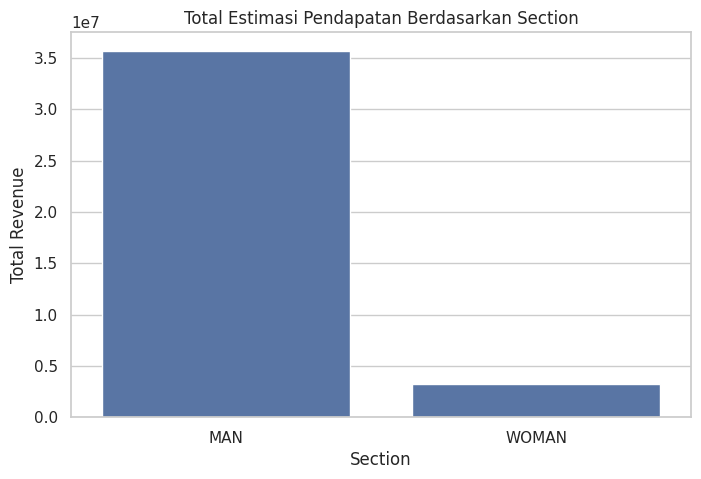

In [ ]:
# Visualisasi total revenue berdasarkan section
plt.figure(figsize=(8,5))
sns.barplot(data=section_analysis, x="section", y="total_revenue")
plt.title("Total Estimasi Pendapatan Berdasarkan Section")
plt.xlabel("Section")
plt.ylabel("Total Revenue")
plt.show()

**Bagian Pria (MAN) vs. Wanita (WOMAN):** Bagian 'MAN' secara signifikan mengungguli bagian 'WOMAN' dalam hal total produk, total volume penjualan, dan total pendapatan. Meskipun bagian 'WOMAN' memiliki volume penjualan rata-rata yang sedikit lebih tinggi, harga rata-rata yang lebih tinggi dan jumlah produk yang jauh lebih besar di bagian 'MAN' mendorong dominasinya secara keseluruhan dalam pendapatan.

In [ ]:
#Analisis berdasarjenis product(terms)
terms_analysis = df.groupby("terms").agg(
    total_produk=("product_id", "count"),
    total_sales_volume=("sales_volume", "sum"),
    average_sales_volume=("sales_volume", "mean"),
    average_price=("price", "mean"),
    total_revenue=("revenue", "sum")
).reset_index().sort_values(by="total_revenue", ascending=False)

terms_analysis

,terms,total_produk,total_sales_volume,average_sales_volume,average_price,total_revenue
0,jackets,140,259468,1853.342857,105.757929,26581815.87
3,sweaters,41,75242,1835.170732,54.862683,4090631.48
2,shoes,31,57906,1867.935484,64.873548,3754837.63
4,t-shirts,32,53637,1676.156250,67.427813,3696806.25
1,jeans,8,13320,1665.000000,63.923750,864385.25


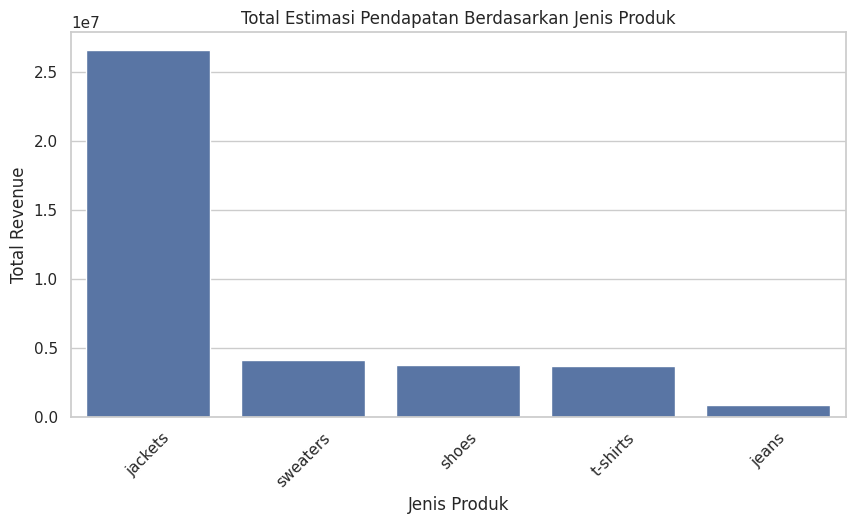

In [ ]:
# Visualisasi revenue berdasarkan jenis produk
plt.figure(figsize=(10,5))
sns.barplot(data=terms_analysis, x="terms", y="total_revenue")
plt.title("Total Estimasi Pendapatan Berdasarkan Jenis Produk")
plt.xlabel("Jenis Produk")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

**Jenis Produk Berkinerja Terbaik:** 'Jaket' adalah jenis produk penghasil pendapatan tertinggi, menyumbang sebagian besar dari total pendapatan. Ini disebabkan oleh harga rata-rata yang tinggi dan sejumlah besar produk dalam kategori ini. 'Sweater', 'sepatu', dan 'kaos' menyusul, dengan 'jeans' memiliki pendapatan terendah.

In [ ]:
#Analisis promosi
promotion_analysis = df.groupby("promotion").agg(
    total_produk=("product_id", "count"),
    total_sales_volume=("sales_volume", "sum"),
    average_sales_volume=("sales_volume", "mean"),
    average_price=("price", "mean"),
    total_revenue=("revenue", "sum")
).reset_index()

promotion_analysis

,promotion,total_produk,total_sales_volume,average_sales_volume,average_price,total_revenue
0,No,132,240312,1820.545455,80.651515,18994089.58
1,Yes,120,219261,1827.175000,92.413667,19994386.90


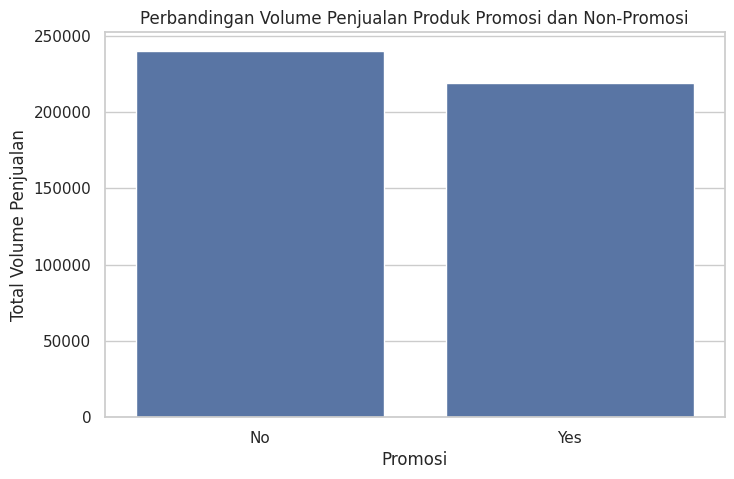

In [ ]:
# Visualisasi perbandingan promosi dan non-promosi
plt.figure(figsize=(8,5))
sns.barplot(data=promotion_analysis, x="promotion", y="total_sales_volume")
plt.title("Perbandingan Volume Penjualan Produk Promosi dan Non-Promosi")
plt.xlabel("Promosi")
plt.ylabel("Total Volume Penjualan")
plt.show()

**Dampak Promosi:** Produk dengan promosi (`Yes`) memiliki total pendapatan yang lebih tinggi dan volume penjualan rata-rata yang sedikit lebih tinggi dibandingkan dengan produk yang tidak dipromosikan (`No`), meskipun jumlah produknya lebih sedikit. Ini menunjukkan bahwa promosi efektif dalam meningkatkan pendapatan dan volume penjualan per produk.

In [ ]:
#Analisis product musiman
seasonal_analysis = df.groupby("seasonal").agg(
    total_produk=("product_id", "count"),
    total_sales_volume=("sales_volume", "sum"),
    average_sales_volume=("sales_volume", "mean"),
    average_price=("price", "mean"),
    total_revenue=("revenue", "sum")
).reset_index()

seasonal_analysis

,seasonal,total_produk,total_sales_volume,average_sales_volume,average_price,total_revenue
0,No,124,226392,1825.741935,86.422903,19156387.82
1,Yes,128,233181,1821.726562,86.087500,19832088.66


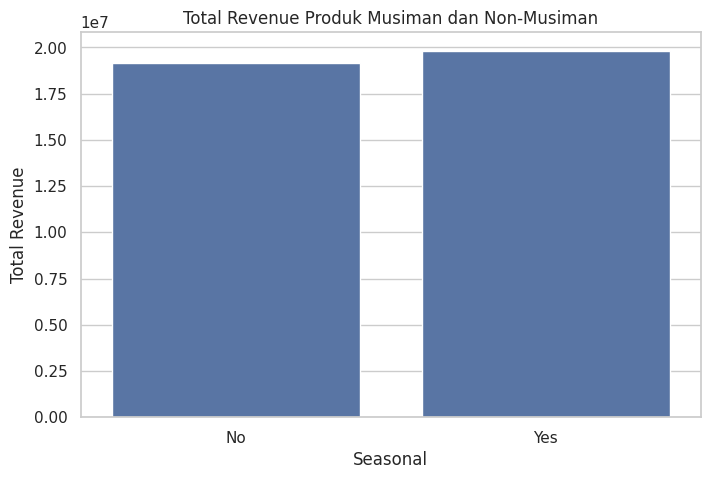

In [ ]:
# Visualisasi produk musiman
plt.figure(figsize=(8,5))
sns.barplot(data=seasonal_analysis, x="seasonal", y="total_revenue")
plt.title("Total Revenue Produk Musiman dan Non-Musiman")
plt.xlabel("Seasonal")
plt.ylabel("Total Revenue")
plt.show()

**Musiman vs. Non-Musiman:** Produk musiman (`Yes`) memiliki total volume penjualan dan total pendapatan yang sedikit lebih tinggi dibandingkan dengan produk non-musiman (`No`). Harga rata-rata untuk kedua kategori sangat mirip. Ini menunjukkan bahwa item musiman sedikit lebih berkontribusi pada kinerja bisnis secara keseluruhan.

In [ ]:
#Analisis posisi product (Aisle, End-cap, Front of Store)
position_analysis = df.groupby("product_position").agg(
    total_produk=("product_id", "count"),
    total_sales_volume=("sales_volume", "sum"),
    average_sales_volume=("sales_volume", "mean"),
    average_price=("price", "mean"),
    total_revenue=("revenue", "sum")
).reset_index().sort_values(by="total_revenue", ascending=False)

position_analysis

,product_position,total_produk,total_sales_volume,average_sales_volume,average_price,total_revenue
0,Aisle,97,177396,1828.824742,88.785773,15481438.43
1,End-cap,86,152930,1778.255814,81.276395,12546465.81
2,Front of Store,69,129247,1873.144928,88.893478,10960572.24


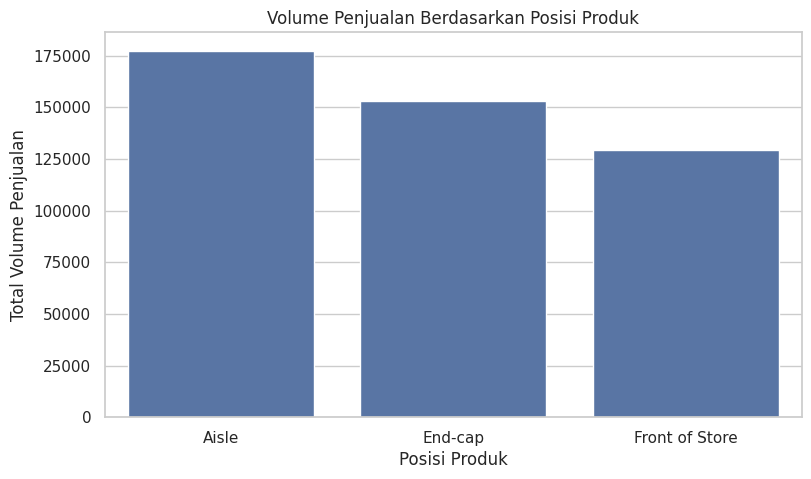

In [ ]:
# Visualisasi posisi produk
plt.figure(figsize=(9,5))
sns.barplot(data=position_analysis, x="product_position", y="total_sales_volume")
plt.title("Volume Penjualan Berdasarkan Posisi Produk")
plt.xlabel("Posisi Produk")
plt.ylabel("Total Volume Penjualan")
plt.show()

**Posisi Produk Terbaik:** Posisi Aisle (Lorong) memberikan kontribusi terbesar terhadap total volume penjualan dan total pendapatan, sehingga menjadi posisi produk dengan kinerja keseluruhan terbaik. Namun, jika dilihat dari rata-rata volume penjualan per produk, Front of Store (Depan Toko) memiliki nilai tertinggi, mengindikasikan bahwa setiap produk yang ditempatkan di area depan toko cenderung terjual lebih banyak dibandingkan produk di posisi lainnya. Sementara itu, End-cap (Ujung Rak) berada pada posisi kedua dalam total penjualan dan pendapatan, tetapi memiliki rata-rata penjualan per produk yang paling rendah.

In [ ]:
#Analisis kategori Harga
price_category_analysis = df.groupby("price_category").agg(
    total_produk=("product_id", "count"),
    total_sales_volume=("sales_volume", "sum"),
    average_price=("price", "mean"),
    total_revenue=("revenue", "sum")
).reset_index().sort_values(by="total_revenue", ascending=False)

price_category_analysis

,price_category,total_produk,total_sales_volume,average_price,total_revenue
0,Mahal,74,131159,144.810811,18693731.00
1,Menengah,107,200553,77.938224,15692720.38
2,Murah,71,127861,37.750000,4602025.10


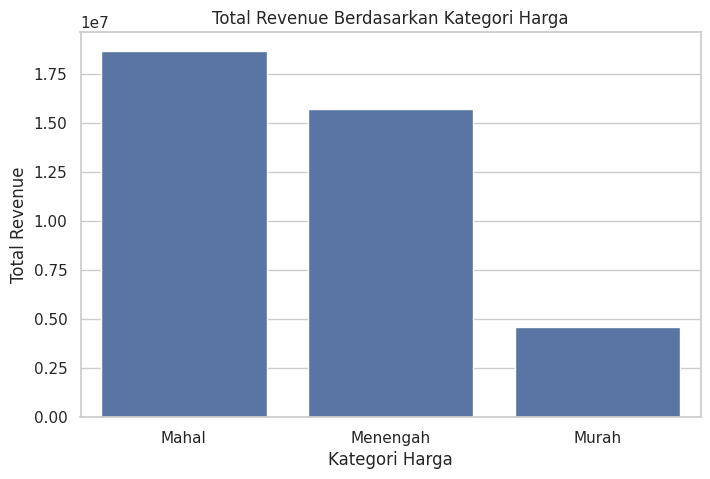

In [ ]:
# Visualisasi kategori harga
plt.figure(figsize=(8,5))
sns.barplot(data=price_category_analysis, x="price_category", y="total_revenue")
plt.title("Total Revenue Berdasarkan Kategori Harga")
plt.xlabel("Kategori Harga")
plt.ylabel("Total Revenue")
plt.show()

**Produk Mahal Mendorong Pendapatan:** Produk 'Mahal' menghasilkan total pendapatan tertinggi, meskipun volume penjualan totalnya lebih rendah dari produk berharga 'Menengah'. Produk 'Menengah' memiliki volume penjualan total tertinggi. Ini menyoroti bahwa meskipun item harga menengah terjual lebih banyak unit, item harga tinggi berkontribusi lebih signifikan terhadap pendapatan keseluruhan. Produk 'Murah' berkontribusi paling sedikit terhadap pendapatan dan volume penjualan.

In [ ]:
# Top 10 Product dengan penjualan tertinggi
top_sales_product = df.sort_values(by="sales_volume", ascending=False).head(10)

top_sales_product[[
    "product_id",
    "name",
    "terms",
    "section",
    "price",
    "sales_volume",
    "revenue",
    "promotion",
    "seasonal",
    "product_position"
]]

,product_id,name,terms,section,price,sales_volume,revenue,promotion,seasonal,product_position
125,183825,PLAID TIE DYE OVERSHIRT,jackets,MAN,19.99,2989,59750.11,Yes,Yes,Aisle
237,123047,SUIT JACKET IN 100% LINEN,t-shirts,MAN,109.00,2985,325365.00,No,Yes,Aisle
246,113435,RIB COLLAR JACKET,jackets,MAN,129.00,2973,383517.00,No,Yes,Aisle
5,117590,CONTRASTING COLLAR JACKET,jackets,MAN,79.90,2968,237143.20,No,No,End-cap
4,192936,DOUBLE FACED JACKET,jackets,MAN,139.00,2942,408938.00,No,Yes,End-cap
34,172364,FAUX LEATHER BOMBER JACKET,jackets,MAN,109.00,2931,319479.00,Yes,No,Aisle
66,137990,COTTON JACKET,jackets,MAN,29.99,2929,87840.71,No,No,Aisle
204,134429,RIPPED STRAIGHT FIT JEANS,jeans,MAN,69.90,2914,203688.60,No,No,Aisle
181,171520,GATHERED WAIST KNIT SWEATER,sweaters,WOMAN,47.90,2901,138957.90,Yes,Yes,End-cap
206,136272,PURL KNIT SWEATER,sweaters,MAN,12.99,2887,37502.13,No,Yes,End-cap


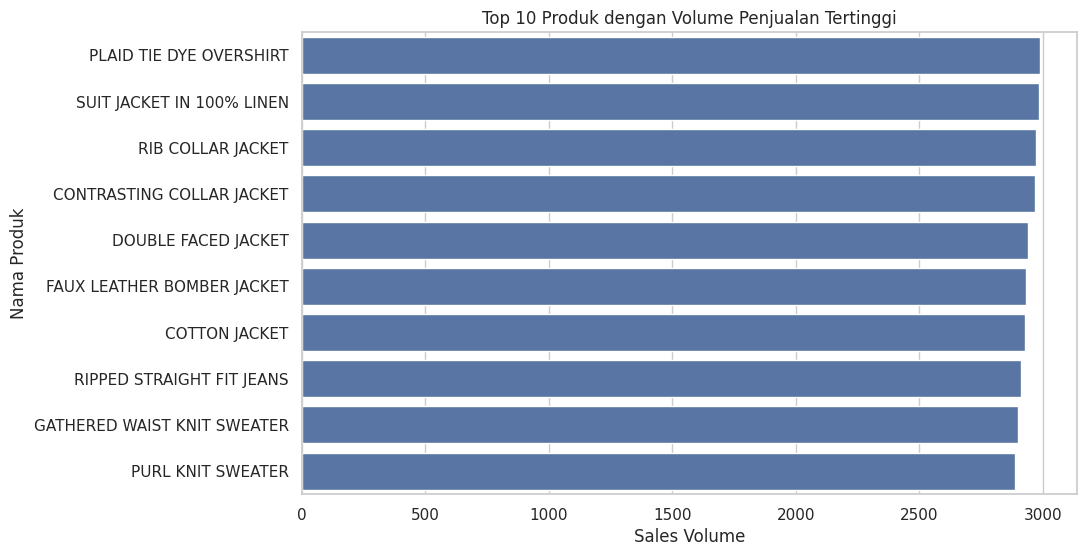

In [ ]:
# Visualisasi top 10 produk berdasarkan volume penjualan

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_sales_product,
    x="sales_volume",
    y="name"
)
plt.title("Top 10 Produk dengan Volume Penjualan Tertinggi")
plt.xlabel("Sales Volume")
plt.ylabel("Nama Produk")
plt.show()

**Penjual Teratas yang Beragam:** Top 10 produk dengan volume penjualan tertinggi terdiri dari berbagai jenis produk, seperti jaket, overshirt, jeans, dan sweater. Hal ini menunjukkan bahwa permintaan pelanggan tidak terfokus pada satu kategori produk saja, melainkan tersebar di beberapa jenis pakaian. Selain itu, seluruh produk dalam daftar memiliki volume penjualan yang relatif tinggi dan hampir seragam, mengindikasikan bahwa produk-produk tersebut merupakan kontributor utama terhadap total penjualan Zara.

Sebagian besar produk dengan volume penjualan tertinggi memiliki harga pada kategori menengah, sehingga menunjukkan bahwa produk dengan harga yang lebih terjangkau cenderung memiliki tingkat permintaan yang lebih tinggi dibandingkan produk premium (mahal).

In [ ]:
#TOP 10 Product dengan revenue tertinggi
top_revenue_product = df.sort_values(by="revenue", ascending=False).head(10)

top_revenue_product[[
    "product_id",
    "name",
    "terms",
    "section",
    "price",
    "sales_volume",
    "revenue",
    "promotion",
    "seasonal",
    "product_position"
]]

,product_id,name,terms,section,price,sales_volume,revenue,promotion,seasonal,product_position
60,151925,VINTAGE EFFECT LEATHER BOMBER JACKET,jackets,MAN,299.0,2179,651521.0,Yes,Yes,End-cap
38,114877,SUEDE JACKET,jackets,MAN,349.0,1860,649140.0,No,No,Aisle
87,152723,LONGLINE QUILTED JACKET,jackets,MAN,169.0,2849,481481.0,No,Yes,Aisle
67,154016,WOOL BLEND TEXTURED JACKET,jackets,MAN,189.0,2366,447174.0,Yes,Yes,End-cap
169,152563,CASHMERE BLEND KNIT SWEATER,sweaters,WOMAN,169.0,2572,434668.0,No,Yes,Front of Store
4,192936,DOUBLE FACED JACKET,jackets,MAN,139.0,2942,408938.0,No,Yes,End-cap
99,137598,POCKET JACKET,jackets,MAN,139.0,2839,394621.0,No,Yes,Aisle
29,110805,FAUX LEATHER OVERSIZED JACKET LIMITED EDITION,jackets,MAN,159.0,2477,393843.0,Yes,No,Front of Store
100,138779,SLIM FIT SUIT JACKET,jackets,MAN,139.0,2801,389339.0,Yes,Yes,Front of Store
22,161909,LEATHER JACKET,jackets,MAN,299.0,1290,385710.0,Yes,No,Aisle


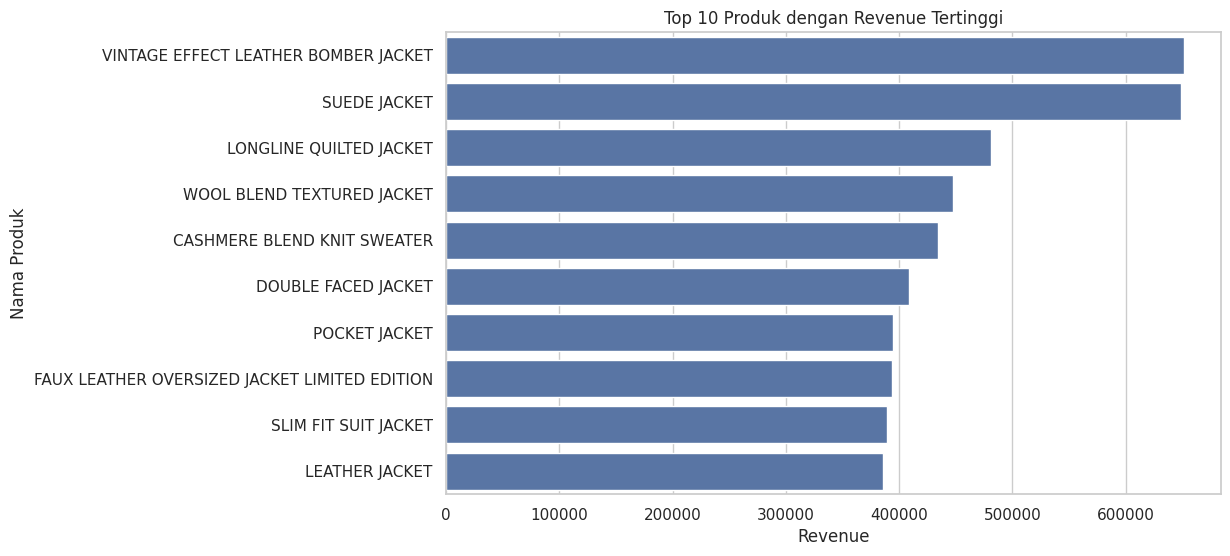

In [ ]:
# Visualisasi top 10 produk berdasarkan revenue
plt.figure(figsize=(10,6))
sns.barplot(
    data=top_revenue_product,
    x="revenue",
    y="name"
)
plt.title("Top 10 Produk dengan Revenue Tertinggi")
plt.xlabel("Revenue")
plt.ylabel("Nama Produk")
plt.show()

**Item Bernilai Tinggi adalah Kunci:** Kategori jaket mendominasi Top 10 revenue dengan 9 dari 10 produk berasal dari kategori tersebut. Produk berharga premium seperti Suede Jacket dan Vintage Effect Leather Bomber Jacket menghasilkan revenue tertinggi, sementara produk dengan harga menengah seperti Double Faced Jacket juga memberikan kontribusi besar karena volume penjualannya yang tinggi. Hal ini menunjukkan bahwa kombinasi harga dan volume penjualan menjadi faktor utama dalam menghasilkan pendapatan.

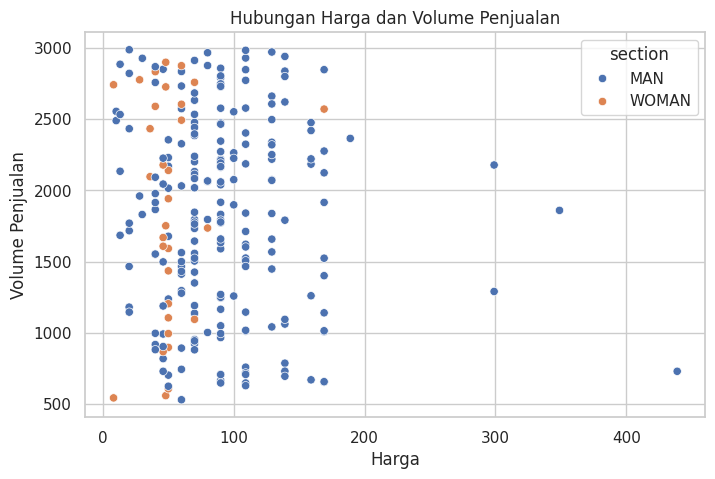

In [ ]:
#analisis hubungan Harga dan Volume Penjualan

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="price",
    y="sales_volume",
    hue="section"
)
plt.title("Hubungan Harga dan Volume Penjualan")
plt.xlabel("Harga")
plt.ylabel("Volume Penjualan")
plt.show()

In [ ]:
# Korelasi antara harga, sales volume, dan revenue

correlation = df[["price", "sales_volume", "revenue"]].corr()
correlation

,price,sales_volume,revenue
price,1.000000,-0.071359,0.753908
sales_volume,-0.071359,1.000000,0.500058
revenue,0.753908,0.500058,1.000000


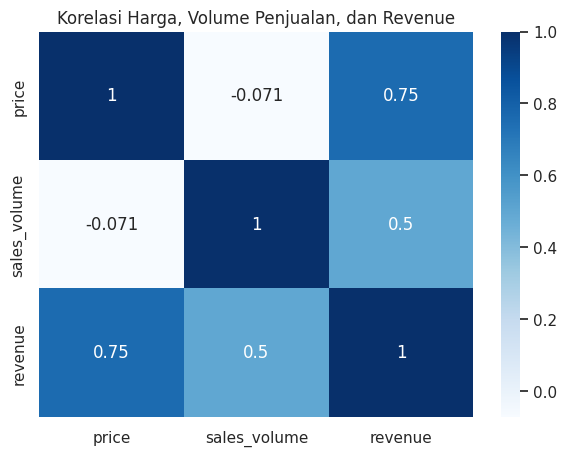

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(correlation, annot=True, cmap="Blues")
plt.title("Korelasi Harga, Volume Penjualan, dan Revenue")
plt.show()

**Harga dan Pendapatan:** Ada korelasi positif yang kuat (0.75) antara `harga` dan `pendapatan`. Ini diharapkan, karena item berharga lebih tinggi umumnya menghasilkan pendapatan yang lebih tinggi, terutama jika dikombinasikan dengan volume penjualan yang layak.

**Volume Penjualan dan Pendapatan:** Ada korelasi positif sedang (0.50) antara `volume_penjualan` dan `pendapatan`. Lebih banyak unit terjual secara logis menghasilkan pendapatan yang lebih tinggi.

**Harga dan Volume Penjualan:** Ada korelasi negatif yang sangat lemah (-0.071) antara `harga` dan `volume_penjualan`. Ini menunjukkan bahwa untuk dataset ini, harga yang lebih tinggi tidak selalu menghalangi volume penjualan secara signifikan, atau bahwa faktor lain lebih kuat memengaruhi volume penjualan, terutama untuk item bernilai tinggi.

## Kesimpulan: Pola Pembelian Pelanggan dan Kinerja Produk Zara

### Pola Pembelian Pelanggan
- **Dominasi Pakaian Pria:** Pelanggan cenderung lebih banyak membeli produk dari bagian 'MAN', yang menghasilkan total pendapatan dan volume penjualan yang jauh lebih tinggi dibandingkan bagian 'WOMAN'. Ini menunjukkan bahwa segmen pria adalah pendorong utama pendapatan bagi Zara dalam dataset ini.
- **Efektivitas Promosi:** Promosi terbukti efektif dalam meningkatkan pendapatan dan sedikit meningkatkan volume penjualan per produk. Pelanggan merespons positif terhadap produk yang dipromosikan, meskipun jumlah produk yang dipromosikan lebih sedikit.
- **Daya Tarik Produk Musiman:** Produk musiman sedikit lebih unggul dalam total volume penjualan dan pendapatan, menunjukkan bahwa pelanggan memiliki preferensi kecil terhadap item yang relevan dengan musim.
- **Pentingnya Penempatan Produk:** Penempatan produk di 'Lorong (Aisle)' dan 'Depan Toko (Front of Store)' memiliki dampak positif pada volume penjualan, dengan 'Lorong' menjadi posisi terbaik untuk total penjualan dan 'Depan Toko' memiliki rata-rata volume penjualan per produk tertinggi.
- **Preferensi Harga Bervariasi:** Pelanggan membeli produk 'Menengah' dalam volume tertinggi, tetapi produk 'Mahal' adalah yang paling signifikan dalam menghasilkan pendapatan total. Ini mengindikasikan bahwa sementara produk terjangkau menarik banyak pembeli, produk premium adalah kunci profitabilitas.

### Kinerja Produk Zara
- **Jaket Sebagai Pendorong Utama:** Kategori 'Jaket' adalah kontributor pendapatan terbesar, berkat kombinasi harga rata-rata yang tinggi dan volume penjualan yang signifikan. Produk-produk jaket premium secara konsisten mendominasi daftar produk dengan pendapatan tertinggi.
- **Korelasi Harga-Pendapatan yang Kuat:** Analisis korelasi menunjukkan hubungan positif yang kuat antara `harga` dan `pendapatan` (0.75), menegaskan bahwa strategi penetapan harga premium untuk produk tertentu berhasil meningkatkan nilai penjualan secara keseluruhan.
- **Volume Penjualan Mendukung Pendapatan:** Terdapat korelasi positif sedang antara `volume_penjualan` dan `pendapatan` (0.50), yang berarti peningkatan jumlah unit yang terjual secara langsung berkontribusi pada pendapatan yang lebih tinggi.
- **Sensitivitas Harga Rendah untuk Volume:** Korelasi negatif yang sangat lemah antara `harga` dan `volume_penjualan` (-0.071) menunjukkan bahwa harga yang lebih tinggi tidak terlalu menghambat volume penjualan secara signifikan dalam konteks dataset ini. Hal ini mungkin karena faktor-faktor seperti merek, kualitas, atau desain memiliki pengaruh yang lebih besar pada keputusan pembelian pelanggan untuk produk Zara.

Secara keseluruhan, Zara menunjukkan kinerja yang kuat di segmen pakaian pria, dengan jaket sebagai kategori produk unggulan yang didukung oleh strategi promosi yang efektif dan penempatan produk yang optimal. Meskipun produk berharga menengah menarik volume penjualan tinggi, produk premium, terutama jaket, adalah Faktor utama yang mendorong pendapatan perusahaan.